# Урожай картофеля в Беларуси, сезон 2025

Аналитический кейс на pandas + matplotlib + plotly. Данные собраны вручную из открытых публикаций Белстата, Минсельхозпрода Республики Беларусь и профильных СМИ — список источников и известные пробелы данных см. в `SOURCES.md`.

**Структура ноутбука:** данные → динамика уборки → охват данных (организованный сектор vs итог года) → регионы → сравнение с другими культурами → выводы → ограничения.

## 1. Импорт и данные

Готового датасета по теме не существует — цифры сведены из разных публикаций с разным охватом (см. `SOURCES.md`).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_colwidth", None)


In [2]:
harvest_timeline = pd.DataFrame({
    "date": pd.to_datetime(["2025-08-27", "2025-09-19", "2025-10-06", "2025-10-24"]),
    "cumulative_kt": [33, 225, 500, 668],          # тыс. тонн, нарастающим итогом
    "yoy_delta_c_ha": [89.1, 30.4, None, None],    # прирост урожайности к 2024, ц/га
})
harvest_timeline


,date,cumulative_kt,yoy_delta_c_ha
0,2025-08-27,33,89.1
1,2025-09-19,225,30.4
2,2025-10-06,500,NaN
3,2025-10-24,668,NaN


In [3]:
scope_comparison = pd.DataFrame({
    "scope": [
        "Организованный сектор (оперативный мониторинг)",
        "Все категории хозяйств (итог года, Белстат)",
    ],
    "volume_kt": [675, 3000],
})
scope_comparison


,scope,volume_kt
0,Организованный сектор (оперативный мониторинг),675
1,"Все категории хозяйств (итог года, Белстат)",3000


In [4]:
regional_breakdown = pd.DataFrame({
    "region": ["Минская", "Могилёвская", "Брестская", "Гомельская", "Остальные области*"],
    "volume_kt": [187, 139, 132, 86, 131],
}).sort_values("volume_kt", ascending=False)
regional_breakdown


,region,volume_kt
0,Минская,187
1,Могилёвская,139
2,Брестская,132
4,Остальные области*,131
3,Гомельская,86


In [5]:
cross_crop = pd.DataFrame({
    "crop": ["Зерновые и зернобобовые", "Сахарная свёкла", "Овощи",
             "Картофель", "Рапс", "Льноволокно"],
    "gross_million_t": [9.1, 5.9, 2.7, 3.0, 0.9103, 0.0583],
    "yield_c_ha": [38.2, 538, 289, None, 20.9, 12.0],
})
cross_crop


,crop,gross_million_t,yield_c_ha
0,Зерновые и зернобобовые,9.1000,38.2
1,Сахарная свёкла,5.9000,538.0
2,Овощи,2.7000,289.0
3,Картофель,3.0000,NaN
4,Рапс,0.9103,20.9
5,Льноволокно,0.0583,12.0


## 2. Палитра и стиль графиков

In [6]:
COLORS = {
    "leaf": "#5F7A45", "leaf_deep": "#43592F",
    "clay": "#A85A2E", "clay_soft": "#D9B98C",
    "ink": "#2A2018", "ink_soft": "#5B4E3D",
    "bg": "#EFE8D8", "grid": "#E0D6BF",
}
plt.rcParams.update({
    "figure.facecolor": COLORS["bg"], "axes.facecolor": "#FBF7EE",
    "axes.edgecolor": COLORS["ink_soft"], "axes.labelcolor": COLORS["ink_soft"],
    "text.color": COLORS["ink"], "xtick.color": COLORS["ink_soft"],
    "ytick.color": COLORS["ink_soft"], "grid.color": COLORS["grid"],
    "font.size": 11, "axes.titleweight": "bold",
})


## 3. Ход уборки: организованный сектор

Минсельхозпрод публикует оперативные сводки по ходу уборки — они отражают только организованный сектор (сельхозорганизации и фермерские хозяйства).

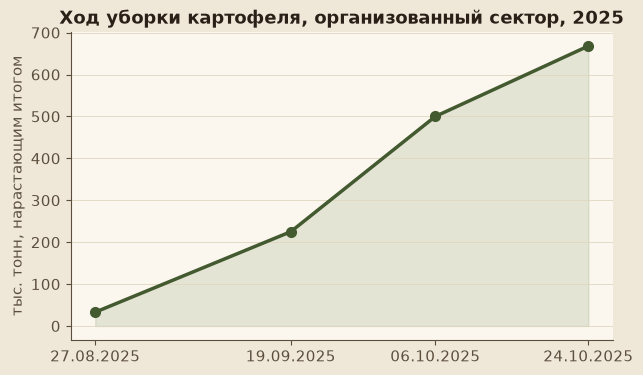

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(harvest_timeline["date"], harvest_timeline["cumulative_kt"],
        marker="o", color=COLORS["leaf_deep"], linewidth=2.5, markersize=7)
ax.fill_between(harvest_timeline["date"], harvest_timeline["cumulative_kt"],
                 color=COLORS["leaf"], alpha=0.15)
ax.set_title("Ход уборки картофеля, организованный сектор, 2025")
ax.set_ylabel("тыс. тонн, нарастающим итогом")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.set_xticks(harvest_timeline["date"])
ax.set_xticklabels(harvest_timeline["date"].dt.strftime("%d.%m.%Y"))
ax.grid(axis="y", linewidth=0.6)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.show()


**Наблюдение.** С 27 августа по 24 октября сбор в организованном секторе вырос с 33 до 668 тыс. тонн. При этом прирост урожайности к 2024 году на 27 августа (+89,1 ц/га) заметно выше, чем на 19 сентября (+30,4 ц/га) — не потому, что урожай «замедлился», а потому что 27 августа было убрано лишь ~33 тыс. т с небольшой площади. **Ранние сезонные сводки — плохая база для годовых выводов.**

## 4. Почему итог в 4,5 раза больше сводок Минсельхозпрода

Итоговые 3 млн тонн (Белстат, все категории хозяйств) включают не только организованный сектор, но и приусадебные/фермерские хозяйства — исторически именно они дают основной объём картофеля в Беларуси.

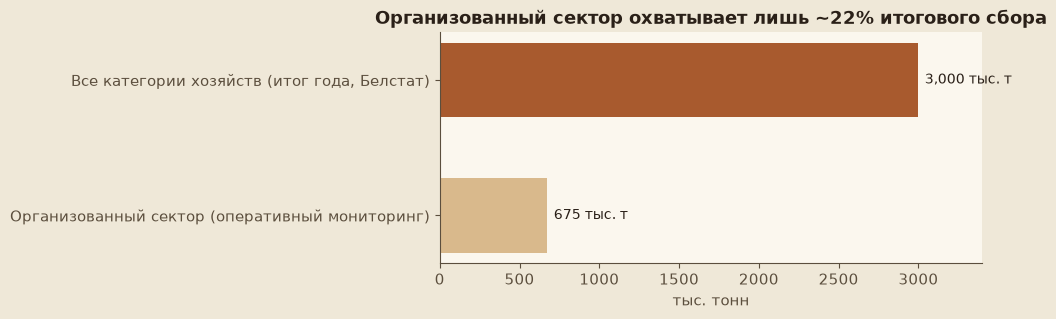

In [8]:
fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(scope_comparison["scope"], scope_comparison["volume_kt"],
               color=[COLORS["clay_soft"], COLORS["clay"]], height=0.55)
for bar, value in zip(bars, scope_comparison["volume_kt"]):
    ax.text(value + 40, bar.get_y() + bar.get_height() / 2, f"{value:,.0f} тыс. т",
            va="center", fontsize=10, color=COLORS["ink"])
ax.set_title("Организованный сектор охватывает лишь ~22% итогового сбора")
ax.set_xlabel("тыс. тонн")
ax.set_xlim(0, 3400)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.show()


**Вывод.** Разница (~2,3 млн т) — это объём вне организованного сектора. По заявлениям Минсельхозпрода, более 60% "второго хлеба" в стране выращивают именно крестьянско-фермерские и частные хозяйства, а не крупные агрокомплексы — это структурная особенность отрасли, а не случайность одного сезона.

## 5. Региональная структура организованного сбора

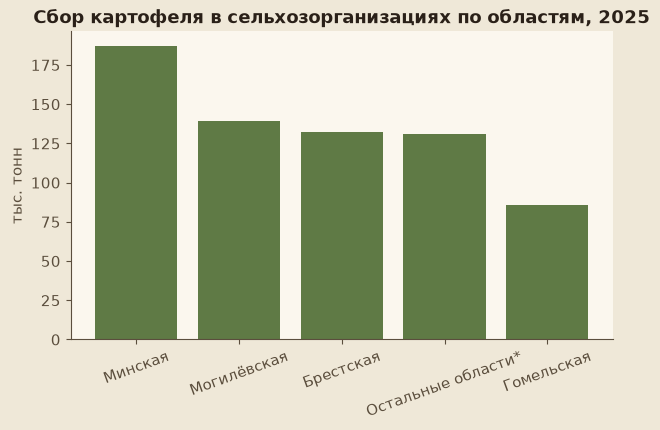

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(regional_breakdown["region"], regional_breakdown["volume_kt"], color=COLORS["leaf"])
ax.set_title("Сбор картофеля в сельхозорганизациях по областям, 2025")
ax.set_ylabel("тыс. тонн")
ax.tick_params(axis="x", rotation=20)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.show()


**Наблюдение.** Минская область — лидер (187 тыс. т, ~28% организованного сбора). Совокупно Минская и Могилёвская области дают почти половину сбора организованного сектора. Разбивка по Гродненской и Витебской областям в источниках не раскрыта — показаны расчётным остатком.

## 6. Картофель на фоне других культур урожая-2025

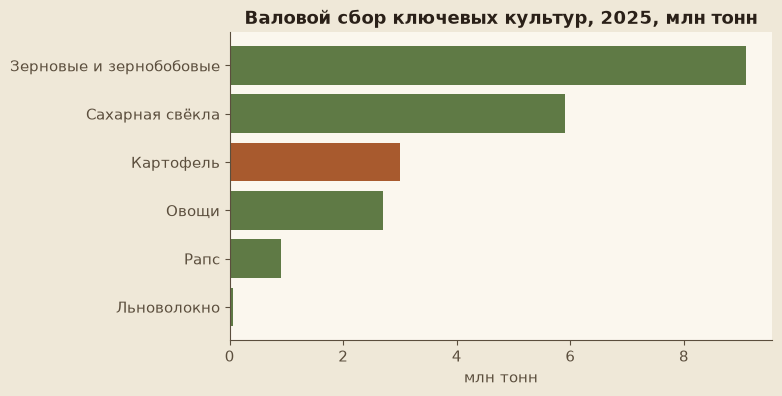

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
order = cross_crop.sort_values("gross_million_t", ascending=True)
colors = [COLORS["clay"] if c == "Картофель" else COLORS["leaf"] for c in order["crop"]]
ax.barh(order["crop"], order["gross_million_t"], color=colors)
ax.set_title("Валовой сбор ключевых культур, 2025, млн тонн")
ax.set_xlabel("млн тонн")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.show()


## 7. Выводы

- Рост к 2024 году подтверждён и по объёму, и по урожайности на всех этапах уборки.
- Плановая площадь посадки была увеличена заранее (с 16,8 до 19,7 тыс. га), по факту вышла ещё выше — 21,8 тыс. га (в охвате оперативного мониторинга).
- Основной объём производства формируют не агрокомплексы, а мелкие и частные хозяйства — сельхозорганизации дают лишь около пятой части итогового сбора страны.
- Минская область — главный организованный производитель, за ней Могилёвская и Брестская области.
- Раннесезонные показатели ненадёжны для прогноза годового результата.

## 8. Ограничения данных

- Нет единой итоговой урожайности картофеля (ц/га) по всем категориям хозяйств за 2025 год — только оперативные срезы по организованному сектору.
- Региональная разбивка раскрыта не по всем 6 областям.
- Официальной трёхсторонней структуры производства (сельхозорганизации / фермерские хозяйства / хозяйства населения) в открытых источниках не найдено.

Полный список источников — в `SOURCES.md`.